In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import KFold, cross_val_score


features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

# merge customer_features with df_train
df = train.merge(features, on="cust_id", how="left")

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# defining returners in target data
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [3]:
# defining features vs target columns for chrun classifier
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [4]:
# fixed 3-way split df_train 60%, df_val 20%, df_cal 20%
X_trainval, X_val, y_trainval, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)
print(f"Train: {len(X_train)}  Cal: {len(X_cal)}  Val: {len(X_val)}")

Train: 69954  Cal: 23318  Val: 23319


In [5]:
# scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

### LGB churn classifier

In [6]:
# LGB training + Optuna opt
cv_opt = KFold(n_splits=3, shuffle=True, random_state=0)

def objective_lgb_clf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 2000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = lgb.LGBMClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        n_jobs=1, verbose=-1, **params
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_opt, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()

study_lgb_clf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgb_clf.optimize(objective_lgb_clf, n_trials=30, show_progress_bar=True)
best_lgb_clf_params = study_lgb_clf.best_params
print(f"LightGBM best params: {best_lgb_clf_params}")
print(f"LightGBM Optuna best AUC: {study_lgb_clf.best_value:.4f}")

lgb_model = lgb.LGBMClassifier(
    random_state=42, scale_pos_weight=scale_pos_weight,
    n_jobs=1, verbose=-1, **best_lgb_clf_params
)
lgb_model.fit(X_train, y_train)

Best trial: 28. Best value: 0.724296: 100%|██████████| 30/30 [06:10<00:00, 12.34s/it]


LightGBM best params: {'n_estimators': 382, 'learning_rate': 0.021748243653343317, 'num_leaves': 30, 'min_child_samples': 15, 'subsample': 0.8546005312408889, 'colsample_bytree': 0.6260057550893929, 'reg_alpha': 0.0028986606804922883, 'reg_lambda': 2.0808584437831717e-06}
LightGBM Optuna best AUC: 0.7243


,boosting_type,'gbdt'
,num_leaves,30
,max_depth,-1
,learning_rate,0.021748243653343317
,n_estimators,382
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,15


In [7]:
# validation trained LGB op df_val: AUC + logloss metrics
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.7252551331651623
Log loss: 0.5994265612292359


In [8]:
# LGB feature importance - top 15
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
46,brand_return_rate,736
8,avg_size,586
1,max_item_revenue,335
15,revenue_recency_ratio,333
0,total_revenue,312
16,discount_per_item,310
14,frequency_recency_ratio,286
11,recency_days,269
19,weighted_revenue,268
39,recency_x_revenue,267


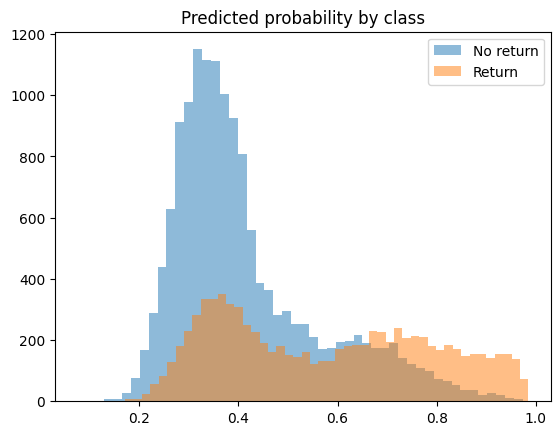

In [9]:
# predicted probability by class - LGB only 
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

### XGB churn classifier

In [10]:
# XGB training + Optuna opt
def objective_xgb_clf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 2000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":             trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }
    model = xgb.XGBClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        use_label_encoder=False, eval_metric="logloss",
        n_jobs=1, verbosity=0, **params
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_opt, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()

study_xgb_clf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb_clf.optimize(objective_xgb_clf, n_trials=30, show_progress_bar=True)
best_xgb_clf_params = study_xgb_clf.best_params
print(f"XGBoost best params: {best_xgb_clf_params}")
print(f"XGBoost Optuna best AUC: {study_xgb_clf.best_value:.4f}")

xgb_model = xgb.XGBClassifier(
    random_state=42, scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric="logloss",
    n_jobs=1, verbosity=0, **best_xgb_clf_params
)
xgb_model.fit(X_train, y_train)

Best trial: 9. Best value: 0.724938: 100%|██████████| 30/30 [06:01<00:00, 12.06s/it]


XGBoost best params: {'n_estimators': 1360, 'learning_rate': 0.015408008522234031, 'max_depth': 3, 'subsample': 0.6554911608578311, 'colsample_bytree': 0.6625916610133735, 'min_child_weight': 15, 'reg_alpha': 0.005470376807480391, 'reg_lambda': 0.9658611176861268, 'gamma': 5.994036749692399e-05}
XGBoost Optuna best AUC: 0.7249


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6625916610133735
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [11]:
# validation trained XGB op df_val: AUC + logloss metrics
p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

XGBoost AUC: 0.7261790061309688
XGBoost LogLoss: 0.5995689507132691


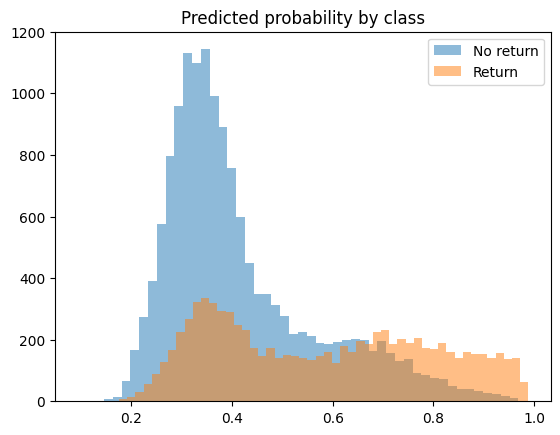

In [12]:
# predicted probability by class - XGB only 
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

### CATBoost churn classifier

In [13]:
# CATBoost training + Optuna opt
def objective_cat_clf(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 300, 2000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "depth":             trial.suggest_int("depth", 3, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
    }
    model = CatBoostClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        loss_function="Logloss", verbose=False,
        thread_count=1, bootstrap_type="Bernoulli", **params
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_opt, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()

study_cat_clf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_cat_clf.optimize(objective_cat_clf, n_trials=20, show_progress_bar=True)
best_cat_clf_params = study_cat_clf.best_params
print(f"CatBoost best params: {best_cat_clf_params}")
print(f"CatBoost Optuna best AUC: {study_cat_clf.best_value:.4f}")

cat_model = CatBoostClassifier(
    random_state=42, scale_pos_weight=scale_pos_weight,
    loss_function="Logloss", verbose=False,
    thread_count=-1, bootstrap_type="Bernoulli", **best_cat_clf_params
)
cat_model.fit(X_train, y_train)

Best trial: 5. Best value: 0.724304: 100%|██████████| 20/20 [13:02<00:00, 39.14s/it]


CatBoost best params: {'iterations': 1675, 'learning_rate': 0.014090340145923627, 'depth': 3, 'subsample': 0.8421165132560784, 'colsample_bylevel': 0.7200762468698007, 'min_child_samples': 21, 'l2_leaf_reg': 0.00028614897264046574}
CatBoost Optuna best AUC: 0.7243


CatBoostClassifier(bootstrap_type='Bernoulli', colsample_bylevel=0.7200762468698007, depth=3, iterations=1675, l2_leaf_reg=0.00028614897264046574, learning_rate=0.014090340145923627, loss_function='Logloss', min_child_samples=21, random_state=42, scale_pos_weight=np.float64(1.732578125), subsample=0.8421165132560784, verbose=False)

In [14]:
# validation trained CATBoost op df_val: AUC + logloss metrics
p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

CatBoost AUC: 0.7260568284477251
CatBoost LogLoss: 0.5999822090903053


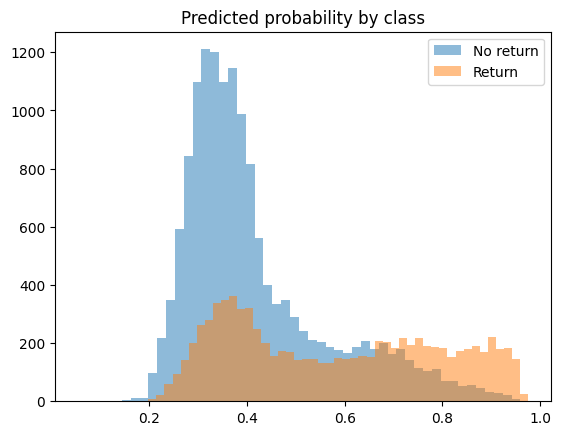

In [15]:
# predicted probability by class - CATBoost only 
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

### comparison of churn classifiers 

In [16]:
# printing of validation scores 3 churn classifiers
results = {
    "LightGBM":     roc_auc_score(y_val, p_val_lgb),
    "XGBoost":      roc_auc_score(y_val, p_val_xgb),
    "CatBoost":     roc_auc_score(y_val, p_val_cat),
}
print("Individual model AUCs:")
for name, auc in results.items():
    print(f"  {name}: {auc:.4f}")

Individual model AUCs:
  LightGBM: 0.7253
  XGBoost: 0.7262
  CatBoost: 0.7261


### Ensemble

In [17]:
# Generation of Ensemble prediction (equal weights)
p_val_ensemble = (p_val_lgb + p_val_xgb + p_val_cat) / 3
ensemble_auc = roc_auc_score(y_val, p_val_ensemble)
ensemble_ll  = log_loss(y_val, p_val_ensemble)
print(f"\nEnsemble (avg) AUC:      {ensemble_auc:.4f}")
print(f"Ensemble (avg) Log Loss: {ensemble_ll:.4f}")


Ensemble (avg) AUC:      0.7264
Ensemble (avg) Log Loss: 0.5992


### Calibration

In [18]:
# generating probabilies on df_cal without calibration
p_cal_lgb = lgb_model.predict_proba(X_cal)[:, 1]
p_cal_xgb = xgb_model.predict_proba(X_cal)[:, 1]
p_cal_cat = cat_model.predict_proba(X_cal)[:, 1]

# Fit calibrators
iso_lgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_lgb, y_cal)
iso_xgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_xgb, y_cal)
iso_cat = IsotonicRegression(out_of_bounds="clip").fit(p_cal_cat, y_cal)

# Calibrated probabilities on df_val
p_val_lgb_cal = iso_lgb.transform(lgb_model.predict_proba(X_val)[:, 1])
p_val_xgb_cal = iso_xgb.transform(xgb_model.predict_proba(X_val)[:, 1])
p_val_cat_cal = iso_cat.transform(cat_model.predict_proba(X_val)[:, 1])
p_val_ensemble_cal = (p_val_lgb_cal + p_val_xgb_cal + p_val_cat_cal) / 3

print(f"Calibrated Ensemble AUC: {roc_auc_score(y_val, p_val_ensemble_cal):.4f}")
print(f"Mean calibrated probability: {p_val_ensemble_cal.mean():.4f}")
print(f"Actual proportion returners: {y_val.mean():.4f}")

Calibrated Ensemble AUC: 0.7266
Mean calibrated probability: 0.3649
Actual proportion returners: 0.3667


In [19]:
# calculation Expected Calibration Error (ECE)
# before and after calibration churn classifier ENSEMBLE (only ensemble)
def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            bin_acc  = labels[mask].mean()
            bin_conf = probs[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels)

ece_raw = compute_ece(p_val_ensemble.values if hasattr(p_val_ensemble, 'values') 
                      else p_val_ensemble, y_val.values)
ece_cal = compute_ece(p_val_ensemble_cal, y_val.values)

print(f"\nECE uncalibrated: {ece_raw:.4f}")
print(f"ECE calibrated:   {ece_cal:.4f}")
print(f"improvement:        {ece_raw - ece_cal:.4f}")

print(f"\n--- Summary Calibration Effect ---")
print(f"{'Metric':<25} {'uncalibrated':<18} {'calibrated':<15} {'Better?'}")
print(f"{'AUC':<25} {roc_auc_score(y_val, p_val_ensemble):<18.4f} "
      f"{roc_auc_score(y_val, p_val_ensemble_cal):<15.4f} "
      f"{'~similar (ranking unchanged)'}")
print(f"{'ECE':<25} {ece_raw:<18.4f} {ece_cal:<15.4f} "
      f"{'✓' if ece_cal < ece_raw else '✗'}")


ECE uncalibrated: 0.1088
ECE calibrated:   0.0078
improvement:        0.1010

--- Summary Calibration Effect ---
Metric                    uncalibrated       calibrated      Better?
AUC                       0.7264             0.7266          ~similar (ranking unchanged)
ECE                       0.1088             0.0078          ✓


In [20]:
# verification presence models folder
import os
os.makedirs("../models", exist_ok=True)


In [21]:
# save churn classifiers + feature_columns + calibrators
feature_cols = X.columns.tolist()
joblib.dump(lgb_model, "../models/churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/churn_xgb_model.pkl")
joblib.dump(cat_model, "../models/churn_cat_model.pkl")
joblib.dump(feature_cols, "../models/feature_columns.pkl")
joblib.dump(iso_lgb, "../models/iso_lgb.pkl")
joblib.dump(iso_xgb, "../models/iso_xgb.pkl")
joblib.dump(iso_cat, "../models/iso_cat.pkl")

['../models/iso_cat.pkl']

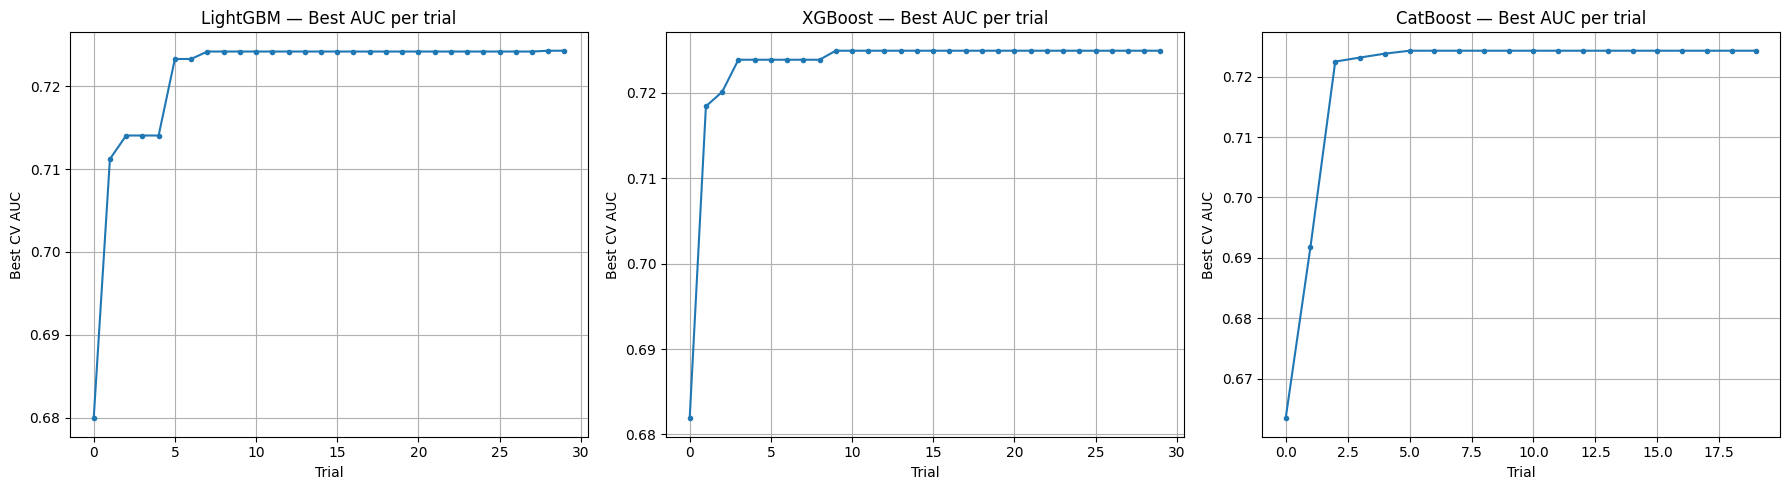

In [22]:
# Optuna plot AUC per trial for 3 churn classifiers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, study, name in zip(axes, 
                            [study_lgb_clf, study_xgb_clf, study_cat_clf],
                            ["LightGBM", "XGBoost", "CatBoost"]):
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = [max(values[:i+1]) for i in range(len(values))]
    ax.plot(best_so_far, marker="o", markersize=3)
    ax.set_title(f"{name} — Best AUC per trial")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Best CV AUC")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# comparison CV AUC vs. df_val AUC for 3 best Optuna trials, for each churn classifier
print(f"{'Trial':<8} {'CV AUC':<12} {'Val AUC':<12}")
print("-" * 34)

for study, name, model_class, base_params in [
    (study_lgb_clf, "LightGBM", lgb.LGBMClassifier, 
     {"random_state": 42, "scale_pos_weight": scale_pos_weight, "n_jobs": -1, "verbose": -1}),
    (study_xgb_clf, "XGBoost", xgb.XGBClassifier, 
     {"random_state": 42, "scale_pos_weight": scale_pos_weight, "n_jobs": -1, 
      "use_label_encoder": False, "eval_metric": "logloss", "verbosity": 0}),
    (study_cat_clf, "CatBoost", CatBoostClassifier, 
     {"random_state": 42, "scale_pos_weight": scale_pos_weight, "thread_count": -1,
      "loss_function": "Logloss", "verbose": False, "bootstrap_type": "Bernoulli"})
]:
    values = [t.value for t in study.trials if t.value is not None]
    params_list = [t.params for t in study.trials if t.value is not None]
    top5_idx = sorted(range(len(values)), key=lambda i: values[i], reverse=True)[:3]
    
    print(f"\n{name}:")
    for idx in top5_idx:
        model = model_class(**base_params, **params_list[idx])
        model.fit(X_train, y_train)
        p_val = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, p_val)
        print(f"  Trial {idx:<4} CV AUC: {values[idx]:.4f}  Val AUC: {val_auc:.4f}")

Trial    CV AUC       Val AUC     
----------------------------------

LightGBM:
  Trial 28   CV AUC: 0.7243  Val AUC: 0.7253
  Trial 7    CV AUC: 0.7242  Val AUC: 0.7252
  Trial 27   CV AUC: 0.7242  Val AUC: 0.7251

XGBoost:
  Trial 9    CV AUC: 0.7249  Val AUC: 0.7262
  Trial 29   CV AUC: 0.7248  Val AUC: 0.7262
  Trial 22   CV AUC: 0.7242  Val AUC: 0.7255

CatBoost:
  Trial 5    CV AUC: 0.7243  Val AUC: 0.7261
  Trial 9    CV AUC: 0.7242  Val AUC: 0.7251
  Trial 15   CV AUC: 0.7240  Val AUC: 0.7254


NameError: name 'p_raw_ensemble' is not defined

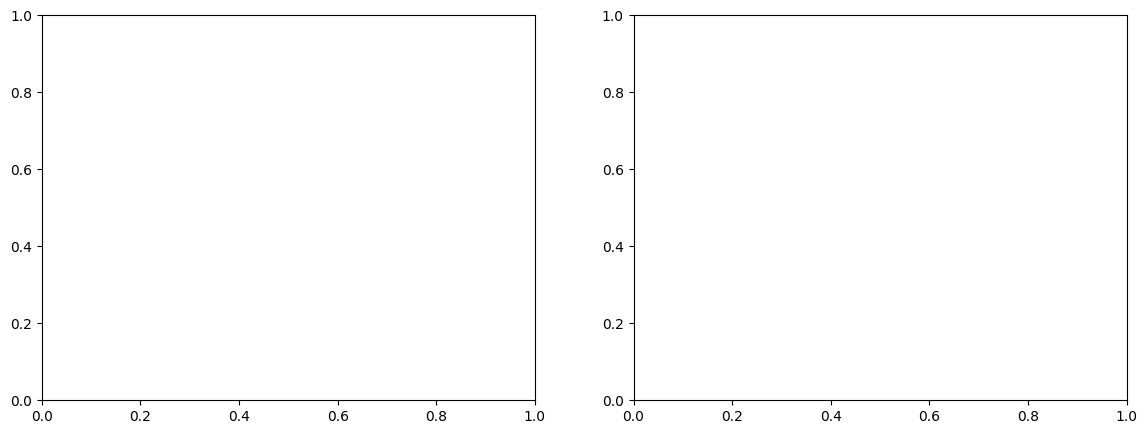

In [ ]:
# plot churn probabilities calibrated vs uncalibrated by true class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title in [
    (axes[0], p_val_ensemble ,  "Uncalibrated ensemble probabilities"),
    (axes[1], p_val_ensemble_cal,  "Calibrated ensemble probabilities (Isotonic)"),
]:
    ax.hist(probs[y_binary == 0], bins=60, alpha=0.55,
            color="#d73027", label="Churners (true revenue = 0)", density=True)
    ax.hist(probs[y_binary == 1], bins=60, alpha=0.55,
            color="#1a9850", label="Returners (true revenue > 0)", density=True)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
               label=f"Threshold = {threshold:.2f}")
    ax.set_xlabel("Predicted return probability")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle("Churn model — predicted return probability by true class",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Extra info
print(f"Calibrated ensemble — churners:  mean prob = {p_val_ensemble_cal[y_val==0].mean():.3f}")
print(f"Calibrated ensemble — returners: mean prob = {p_val_ensemble_cal[y_val==1].mean():.3f}")
print(f"Overlap zone (0.3–0.7): "
      f"{((p_val_ensemble_cal> 0.3) & (p_val_ensemble_cal < 0.7)).mean()*100:.1f}% of customers")